# 实验一 最近邻分类器


**作业要求：**  
**1. 将最近邻分类器的距离度量方法修改为”L2距离“，给出分类精度；**  
**2. 分析K取不同值对分类结果的影响，把精度随k值的变化曲线，使用matplotlib库画出**  
**3. 使用MNIST数据，建立一个线性分类器，使用随机搜索算法，更新参数，分析实验结果。**  

**代码构建思路：**  
**1. 彻底改写KNN类的各个实例方法，换曼哈顿距离为欧几里得距离**  
**2. 在KNN类实例方法__init__()中增加新的参数k（在KNN算法中，k是超参数），作为一个KNN类实例的k的值，然后构建基于k的for循环，记录中间值，绘制图像即可**  
**3. 创建一个线性分类器类LinearClassifier，其中实例方法train可以用来更新实例属性最佳损失best_loss和最佳权重best_W，predict可以用来预测标签**

## 读取MNIST数据集，并将其划分为train/val/test数据集

**注：**  
**-train即“训练”，与训练集相关的变量名字里常带有train**  
**-val即“validation”的缩写，与验证集相关的变量名字里常带有val**  
**-test即“测试”，与测试集相关的变量名字里常带有test**

### MNIST数据集读取

In [8]:
import gzip  #一个python内置库，用于读取.gz后缀的格式压缩文件（见本实验所用到的MNIST数据集的详细组成）
import os  #os即“operation system”操作系统的首字母简写，多用该库内的path.join()来拼接文件的路径
import struct  #一个python内置库，用于将二进制字节串bytes转换为python能识别的int、float等数据类型（也是因为MNIST内部数据特殊才需要导入这个库）
import numpy as np  #numpy是一个与数值计算强相关的第三方库，我们约定俗成将其简写为np
import matplotlib.pyplot as plt  #用于第2问，科学绘图常用

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    """下面是一种'软编码'(softcode)的方式，比起'硬编码'(hardcode)更加灵活便捷"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    """下面是通过‘上下文管理器’的方式来打开文件，比起‘手动管理’更为安全、简洁"""
    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):  #ratio是'比率'的意思，此指训练集和测试集的划分比例
    
    total_len = images.shape[0]  #.shape可以获取一个n维数组的维度，然后返回一个元组，元素就是其各个维度的值
                                 #而images是一个二维数组，其行数就是样本数，列数则是一个图片的像素数（28*28=728），也就是说我们把一张图片压缩成了一行数
    
    offset = int(total_len * ratio)  #offset是分界线，下标小于offset的划分到训练集里去，大于offset的划分到验证集里去
    
    val_img = images[:offset][:]  #此处用到了python中的切片，不做过多解释
    val_lb = labels[:offset]
    
    train_img = images[offset:][:]
    train_lb = labels[offset:]
    
    return train_img, train_lb, val_img, val_lb    

### 按照 5:1:1 划分为训练集，验证集，测试集


In [9]:
# 读取训练集和测试集数据
[images, labels] = load_mnist('./MNIST', kind='train')  #关于'.''/'，这些属于'文件系统路径表示符'，常用于命令行等场景
[test_img, test_lb] = load_mnist('./MNIST',kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)


# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape)

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,)


**！！！需要特别注意的是，标签的shape返回的是一个单元素的元组，这意味着它们都是一维数组，需要保持维度上的一致性**  
**！！！否则在计算准确率时会因为ndarray的切片特性而造成计算错误，我们会在后面讲到**

## 最近邻分类器

### 定义 Nearest Neighbor Classifier

In [10]:
import numpy as np

class NearestNeighbor(object):
    """很多时候我们会将一个机器学习或深度学习算法抽象成一个类(Class)"""
    """而其中的一些计算过程我们会编写成实例方法"""
    """这需要你对'面向对象编程'（OPP,Object Oriented Programming）有一定的了解"""
    
    def __init__(self,k):  #!!!修改，为实现作业任务中的第2问，我们在__init__实例方法中新增一个参数k
        self.k=k
    
    # 读入图像和标签数据并保存
    def train(self, X, y):
        # X is N x D and Y is 1-dimension of size N
        self.Xtrain = X.astype(np.int32)  #!!!修改，此处不能直接读取X，因为无论是L1还是L2距离，都会涉及不同样本中不同像素点像素值的减法运算
                                          #由于ubyte是无符号的（此处u就是unsigned），意为着如果计算结果是负数则会触发'数值溢出'，给出不符合数学预期的结果
                                          #例如5-10应该是-5，但实际上会给出256+(-5)=251，这实际上对256做了取模运算
                                          #因此需要使用astype强制转换数据类型，否则L1和L2算法计算距离将毫无意义可言
        
        self.ytrain = y  #y可以用astype改，但也可以不改，因为不会像X那样涉及越界的风险
    
    # 按照最近邻原则分类
    def get_knn_indices(self, x):  #!!!修改，为解决第2问，我们对原方法做出了一定的修改
        """L1是曼哈顿距离，对于n维空间中两个点，L1距离就是两者各维度上坐标之差的绝对值之和"""
        """下面改用L2欧几里得距离，对于n维空间中两个点，L2距离就是两者各维度上坐标之差的平方之和"""
        distances2=np.sum(np.square(self.Xtrain-x),axis=1)  #axis可以控制在哪个维度上进行运算，本实验中只涉及二维，故axis取0或1，但是默认值是0
                                                                #详细用法不多赘述，请自行查询
        knn_indices=np.argsort(distances2)  #np.argsort()可以获取排序后元素的下标
                                            #例如对于np.array([4,2,7,3]),使用np.argsort()后返回结果为[1,3,0,2]
        knn_indices=knn_indices[0:self.k]  #只返回前k个
        return knn_indices
        

    def get_label(self,x):  #注意这里是小写的x，针对的是某一个样本
        knn_indices=self.get_knn_indices(x)  #获取某一个样本的knn_indices

        label_statistic=np.zeros(10)  #因为MNIST中只有0~9这10种数字，故label_statistic的shape为(10,)

        for index in knn_indices:
            label=self.ytrain[index]
            label_statistic[label]+=1

        return np.argmax(label_statistic)  #返回所有标签中数量最多的那一种标签
    
    
    def predict(self,X):  #注意这里是大写的X，针对的是若干个样本
        predicted_labels=np.zeros(X.shape[0],dtype=int)

        for i,x in enumerate(X):  #enumerate()是python自带的函数，如果传入一个可迭代对象，可以同时拿到其索引和元素，比较方便
                                  #当然也不是必须的，下标用i，元素用X[i]效果也是一样的                        
            predicted_labels[i]=self.get_label(x)

        return predicted_labels
            

### 测试 Nearest Neighbor Classifier

In [11]:
# 实例化Nearest Neighbor Classifier
nn = NearestNeighbor(1)  #!!!修改，因为第2问涉及了k这个超参数的取值，故第一次我们不妨设置k=1
                         #当然你也可以不传入参数，不过这样就得给在__init__()中给k设置默认值了

np.random.seed(0)  #随便选取一个种子，不妨取0
idx=np.random.permutation(np.arange(1000))  #将0~999这些数字乱序并生成一个一维数组
                                            #之所以这么做是因为MNIST数据集中同种数字都是排在一起的，如果不做预处理可能会导致模型学不到东西
                                            #造成欠拟合等问题
train_img=train_img[idx]
train_lb=train_lb[idx]
val_img=val_img[idx]
val_lb=val_lb[idx]

nn.train(train_img[0:1000], train_lb[0:1000])
Yval_predict = nn.predict(val_img[0:1000])

# 在验证集上测试精确度
"""
现在我们来详细讲一下为什么标签之间如果维度不统一会造成准确率大幅下降：
假如我们之前没有做修改，那么此处Yval_predict会是一个shape为(n,1)的二维数组，而val_lb是一个shape为(n,)的一维数组
两者无法直接进行布尔运算('==')，所有会触发np的'广播'机制(BroadCasting)
我们来看一个简单的例子：
eg.  Yval_predict=np.array([[1],[2],[3]]) && val_lb=np.array([1,2,3])
     当执行Yval_predict == val_lb时其实比较的是([[1,1,1]  和  ([[1,2,3]
                                               [2,2,2]        [1,2,3]
                                               [3,3,3]])      [1,2,3]])
     显然比较的结果是([[True,False,False]
                      [False,True,False]
                      [False,False,True]])
     而np.mean()默认axis=None,也就是会对所有元素取均值，这就会导致准确率大幅下降
     看似Yval_predict和val_lb完全相等，准确率为100%,实际上准确率为33.3%
"""
validation_accuracy = np.mean(Yval_predict == val_lb[0:1000])
print ('accuracy: %f' % (validation_accuracy ,))

accuracy: 0.877000


In [12]:
#下面我们来试着解决第2问
np.random.seed(0)
idx=np.random.permutation(1000)

train_img=train_img[idx]
train_lb=train_lb[idx]
test_img=test_img[idx]
test_lb=test_lb[idx]

accuracies=[]  #用来存储k取不同值时的

for k in range(1,11):
    knn=NearestNeighbor(k)
    knn.train(train_img[0:1000],train_lb[0:1000])

    predicted_labels=knn.predict(test_img[0:1000])
    accuracy=np.mean(predicted_labels==test_lb)
    print(f'当k的值为{k}时，模型预测准确率为：{accuracy*100:.4f}%')
    accuracies.append(accuracy)

当k的值为1时，模型预测准确率为：83.8000%
当k的值为2时，模型预测准确率为：81.2000%
当k的值为3时，模型预测准确率为：82.5000%
当k的值为4时，模型预测准确率为：82.0000%
当k的值为5时，模型预测准确率为：81.0000%
当k的值为6时，模型预测准确率为：81.7000%
当k的值为7时，模型预测准确率为：80.8000%
当k的值为8时，模型预测准确率为：80.8000%
当k的值为9时，模型预测准确率为：79.4000%
当k的值为10时，模型预测准确率为：80.4000%


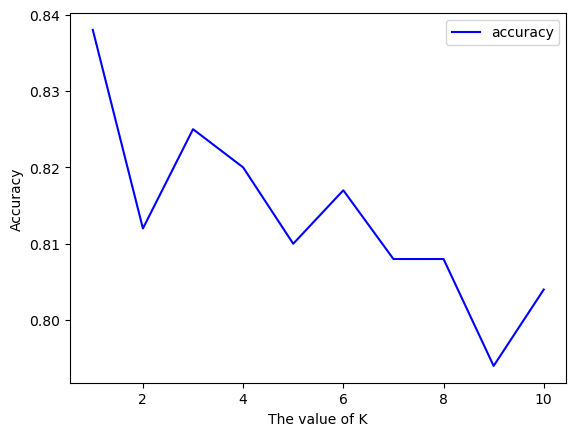

In [13]:
#绘制准确率随着超参数k变化的图像
plt.figure()
plt.plot(np.arange(1,11),accuracies,color='blue',label='accuracy')
plt.xlabel('The value of K')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 线性分类器

### 定义 Linear Classifier

In [39]:
class LinearClassifier():
    def __init__(self):
        self.best_loss=float('inf')  #初始化损失为inf
        self.best_W=None  #初始化W为None

    
    def train(self,train_X,train_Y,W):
        """train_X的shape为(N,728),train_Y的shape为(N,),W的shape为(10,729)"""
        """
        显然此时W的shape[1]从728变成了729，这是因为采用的是线性模型，我们会在每一个样本后面加上一个固定值为1的特征，在Y=W@X.T中，这个1
        和W中的w0相乘后得到的w0就可以看做是偏置b，也就成了我们熟知的'y=kx+b'，但是这会改变train_X的shape    
        """
        train_X=np.concatenate([train_X,np.ones((train_X.shape[0],1))],axis=1)
        
        scores=(W@train_X.T).T  #scores的shape为(N,10)
        
        scores_shifted=scores-np.max(scores,axis=1,keepdims=True)  #每个样本减去当前样本下的最大值不影响softmax正确性
        exp_scores=np.exp(scores_shifted)
        probs=exp_scores/np.sum(exp_scores,axis=1,keepdims=True)  #获取每个样本对于10个标签的概率

        correct_logprobs=-np.log(probs[np.arange(len(train_Y)),train_Y])  #计算交叉熵损失
        loss=np.mean(correct_logprobs)

        return loss

    
    def predict(self,test_X,test_Y):
        test_X=np.concatenate([test_X,np.ones((test_X.shape[0],1))],axis=1)

        scores=(self.best_W@test_X.T).T

        scores_shifted=scores-np.max(scores,axis=1,keepdims=True)
        exp_scores=np.exp(scores_shifted)
        probs=exp_scores/np.sum(exp_scores,axis=1,keepdims=True)

        predicted_labels=np.argmax(probs,axis=1)
        accuracy=np.mean(predicted_labels==test_Y)

        return accuracy

### 测试 Linear Classifier

In [40]:
np.random.seed(0)
idx=np.random.permutation(1000)

train_img=train_img[idx]
train_lb=train_lb[idx]
val_img=val_img[idx]
val_lb=val_lb[idx]
test_img=test_img[idx]
test_lb=test_lb[idx]

lc=LinearClassifier()
lc.best_W=None
lc.best_loss=float('inf')

for i in range(1000):
    W=np.random.randn(10,train_img.shape[1]+1)*0.0001  #乘上一个较小的数字，可以防止爆炸
    loss=lc.train(train_img[0:1000],train_lb[0:1000],W)
    
    if(loss<lc.best_loss):
        lc.best_loss=loss
        lc.best_W=W

    if i%100==0:
        print(f'当前循环次数为:{i}，当前损失为:{loss}，历史最佳损失为:{best_loss}')

当前循环次数为:0，当前损失为:2.3376447000437865，历史最佳损失为:2.244873661778464
当前循环次数为:100，当前损失为:2.3127294550156385，历史最佳损失为:2.244873661778464
当前循环次数为:200，当前损失为:2.34113852409583，历史最佳损失为:2.244873661778464
当前循环次数为:300，当前损失为:2.344826895094046，历史最佳损失为:2.244873661778464
当前循环次数为:400，当前损失为:2.288120037484593，历史最佳损失为:2.244873661778464
当前循环次数为:500，当前损失为:2.384080608004854，历史最佳损失为:2.244873661778464
当前循环次数为:600，当前损失为:2.36735971486193，历史最佳损失为:2.244873661778464
当前循环次数为:700，当前损失为:2.337761353905603，历史最佳损失为:2.244873661778464
当前循环次数为:800，当前损失为:2.343985487838269，历史最佳损失为:2.244873661778464
当前循环次数为:900，当前损失为:2.3610075356178166，历史最佳损失为:2.244873661778464


In [43]:
accuracy=lc.predict(test_img,test_lb)
print(f'模型预测准确率为：{accuracy*100:.4f}')


模型预测准确率为：14.0000


**可以看出随机搜索算法的准确率非常的低**

In [ ]:
"""完结撒花""""

"""
//
//                       _oo0oo_
//                      o8888888o
//                      88" . "88
//                      (| -_- |)
//                      0\  =  /0
//                    ___/`---'\___
//                  .' \\|     |// '.
//                 / \\|||  :  |||// \
//                / _||||| -:- |||||- \
//               |   | \\\  - /// |   |
//               | \_|  ''\---/''  |_/ |
//               \  .-\__  '-'  ___/-. /
//             ___'. .'  /--.--\  `. .'___
//          ."" '<  `.___\_<|>_/___.' >' "".
//         | | :  `- \`.;`\ _ /`;.`/ - ` : | |
//         \  \ `_.   \_ __\ /__ _/   .-` /  /
//     =====`-.____`.___ \_____/___.-`___.-'=====
//                       `=---='
//
//
//     ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
//
//                     佛祖保佑无bug
"""